# MobileSAM single-point inference

This notebook shows the simplest `pip install` flow for `mobilesam-lite` and a minimal single-point prompt inference example.

Before running the inference cells, download a MobileSAM checkpoint such as `mobile_sam.pt` from the official MobileSAM release assets and set `CHECKPOINT_PATH` below. The Python package does not bundle weights.

In [1]:
%pip install mobilesam-lite

     |████████████████████████████████| 728 kB 7.9 MB/s eta 0:00:01
  Using cached numpy-1.24.4-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Using cached pillow-10.4.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.4 MB)
  Using cached timm-1.0.26-py3-none-any.whl (2.6 MB)
  Using cached torch-2.4.1-cp38-cp38-manylinux1_x86_64.whl (797.1 MB)
  Using cached PyYAML-6.0.3-cp38-cp38-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (806 kB)
  Using cached scipy-1.10.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.5 MB)
  Using cached requests-2.32.4-py3-none-any.whl (64 kB)
  Using cached torchvision-0.19.1-cp38-cp38-manylinux1_x86_64.whl (7.0 MB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
     |████████████████████████████████| 9.2 MB 3.7 MB/s eta 0:00:01
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (70.5 MB)
  Using cached huggingface_hub-0.36.2-py3-none-any.

## Configure paths

Set `CHECKPOINT_PATH` to your downloaded `mobile_sam.pt` file.

If `IMAGE_PATH` is left as `None`, the notebook creates a simple synthetic test image so you can still verify the full prompt flow.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from mobilesam_lite.mobile_sam import SamPredictor, sam_model_registry

CHECKPOINT_PATH = Path("../weight/mobile_sam.pt")
IMAGE_PATH = "../asset/input.png"
POINT_XY = np.array([[1850, 512]], dtype=np.float32)
POINT_LABELS = np.array([1], dtype=np.int32)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
def load_image(image_path):
    if image_path is None:
        image = np.zeros((1024, 1024, 3), dtype=np.uint8)
        image[220:820, 220:820, 1] = 180
        image[320:720, 320:720, 0] = 255
        return image

    image = Image.open(image_path).convert("RGB")
    return np.array(image)


if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Download mobile_sam.pt and update CHECKPOINT_PATH first."
    )

image = load_image(IMAGE_PATH)
image.shape

(1500, 2250, 3)

In [17]:
model = sam_model_registry["vit_t"](checkpoint=str(CHECKPOINT_PATH))
model = model.to(device)
model.eval()

predictor = SamPredictor(model)
predictor.set_image(image)

masks, scores, logits = predictor.predict(
    point_coords=POINT_XY,
    point_labels=POINT_LABELS,
    multimask_output=True,
)

best_idx = int(np.argmax(scores))
best_mask = masks[best_idx]
best_score = float(scores[best_idx])

best_score

0.9952951669692993

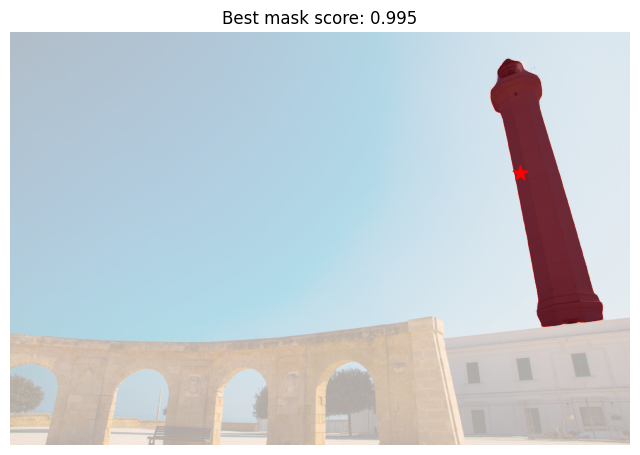

In [19]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.imshow(best_mask, alpha=0.7, cmap="Reds")
plt.scatter(POINT_XY[:, 0], POINT_XY[:, 1], c="red", s=120, marker="*")
plt.title(f"Best mask score: {best_score:.3f}")
plt.axis("off")
plt.show()

## Notes

- Use foreground clicks with label `1` and background clicks with label `0`.
- For multiple clicks, pass more rows in `POINT_XY` and matching values in `POINT_LABELS`.
- If you want just one mask instead of three candidates, set `multimask_output=False`.